<a href="https://colab.research.google.com/github/Ladyjinxxx/codveda-machine-learning-internship/blob/main/Level3_Task2_SVM_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Level 3 - Task 2: Support Vector Machine (SVM) for Classification
### Codveda Technologies Machine Learning Internship

**Dataset:** Sentiment dataset (social media posts)

In [1]:
# Cell 1: Mount Google Drive
# Connects this notebook to Google Drive so we can access the dataset and save outputs.

from google.colab import drive
drive.mount('/content/drive')

# Set the main project folder path
project_path = '/content/drive/MyDrive/Codveda_Internship/Level3_Task2_SVM_Sentiment'

Mounted at /content/drive


In [2]:
# Cell 2: Install Libraries
# Colab already comes with pandas, numpy, matplotlib, seaborn, and scikit-learn pre-installed.
# No additional installation is needed, so this cell just upgrades scikit-learn to be safe.

!pip install -q --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 76.2 MB/s eta 0:00:00


In [3]:
# Cell 3: Import Libraries
# Only the libraries actually used in this notebook are imported.

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

# Set a clean visual style for all plots
sns.set_style('whitegrid')

In [4]:
# Cell 4: Define File Paths
# Set up the dataset path and organize outputs into clear subfolders.

base_path = Path(project_path)
dataset_path = base_path / 'Sentiment dataset.csv'

output_path = base_path / 'outputs'
charts_path = output_path / 'charts'
tables_path = output_path / 'tables'
model_path = output_path / 'model'

# Create the output folders if they don't already exist
for folder in [charts_path, tables_path, model_path]:
    folder.mkdir(parents=True, exist_ok=True)

In [6]:
# Cell 5: Load the Dataset
# Read the sentiment dataset and take a first look at it.

df = pd.read_csv(dataset_path)

# Some columns have extra leading/trailing spaces from how the CSV was saved, so clean those up
df.columns = df.columns.str.strip()
for col in ['Text', 'Sentiment', 'Platform', 'Country']:
    df[col] = df[col].astype(str).str.strip()

# First five rows give a quick preview of the actual values
print("First 5 rows:")
display(df.head())

# Shape tells us how many posts (rows) and features (columns) we have
print(f"\nDataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

# Column names show what information is available for each post
print("\nColumn names:")
print(df.columns.tolist())

# Data types tell us which columns are numerical vs categorical/text
print("\nData types:")
print(df.dtypes)

First 5 rows:


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19



Dataset shape: 732 rows, 15 columns

Column names:
['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']

Data types:
Unnamed: 0.1      int64
Unnamed: 0        int64
Text             object
Sentiment        object
Timestamp        object
User             object
Platform         object
Hashtags         object
Retweets        float64
Likes           float64
Country          object
Year              int64
Month             int64
Day               int64
Hour              int64
dtype: object


In [7]:
# Cell 6: Exploratory Data Analysis (EDA)
# Check data quality and understand the target column before preprocessing.

# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# The raw 'Sentiment' column is very fine-grained (specific emotions like
# 'Joy', 'Despair', 'Curiosity' instead of a simple Positive/Negative label)
print(f"\nNumber of unique sentiment labels in the raw column: {df['Sentiment'].nunique()}")
print("\nMost common raw sentiment labels:")
print(df['Sentiment'].value_counts().head(10))

# Summary statistics for the numerical engagement columns
print("\nDescriptive statistics for numerical columns:")
display(df[['Retweets', 'Likes']].describe())

Missing values per column:
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

Number of duplicate rows: 0

Number of unique sentiment labels in the raw column: 191

Most common raw sentiment labels:
Sentiment
Positive       45
Joy            44
Excitement     37
Contentment    19
Neutral        18
Gratitude      18
Curiosity      16
Serenity       15
Happy          14
Despair        11
Name: count, dtype: int64

Descriptive statistics for numerical columns:


,Retweets,Likes
count,732.000000,732.000000
mean,21.508197,42.901639
std,7.061286,14.089848
min,5.000000,10.000000
25%,17.750000,34.750000
50%,22.000000,43.000000
75%,25.000000,50.000000
max,40.000000,80.000000


In [8]:
# Cell 7: Data Preprocessing
# Prepare the text and the target label so the dataset works for BINARY SVM classification.

# --- Step 1: Build a binary Positive/Negative target ---
# The task calls for binary classification, but the raw 'Sentiment' column has
# over 190 fine-grained emotion labels (Joy, Nostalgia, Despair, Curiosity, etc).
# To get a clean binary target, similar-meaning emotions are grouped into two
# categories using keyword-based matching. Labels that are genuinely ambiguous
# or neutral (e.g. 'Neutral', 'Confusion', 'Surprise') are dropped so the
# remaining classes are clearly Positive or Negative.

positive_keywords = ['joy', 'happ', 'positive', 'excitement', 'content', 'gratitude', 'grateful',
    'curiosity', 'serenity', 'hope', 'pride', 'proud', 'elation', 'euphoria', 'enthusiasm',
    'determination', 'playful', 'inspir', 'love', 'admiration', 'calm', 'compassion', 'tenderness',
    'fulfillment', 'reverence', 'satisfaction', 'accomplishment', 'harmony', 'creativity', 'wonder',
    'adventure', 'awe', 'amusement', 'anticipation', 'kind', 'confident', 'empowerment', 'thrill',
    'enchant', 'radiance', 'rejuvenation', 'coziness', 'resilience', 'exploration', 'captivation',
    'tranquility', 'blessed', 'optimism', 'freedom', 'celebration', 'charm', 'ecstasy', 'triumph',
    'breakthrough', 'relief', 'success', 'friendship', 'romance', 'energy', 'engagement', 'touched',
    'heartwarming', 'positivity', 'kindness', 'appreciation', 'confidence', 'motivation', 'elegance',
    'mindfulness', 'festive', 'spark', 'marvel', 'amazement', 'colorful', 'connection', 'iconic',
    'vibrancy', 'mesmerizing', 'magic', 'beauty', 'celestial', 'thrilling', 'culinary', 'artistic',
    'dazzle', 'dreamchaser', 'innerjourney', 'melodic', 'overjoyed', 'enjoyment', 'affection',
    'adoration', 'zest', 'whimsy', 'empathetic', 'free-spirited', 'solace', 'renewed',
    "nature's beauty", 'runway', 'ocean']

negative_keywords = ['sad', 'despair', 'grief', 'loneliness', 'hate', 'bad', 'disgust', 'bitterness',
    'bitter', 'frustrat', 'betrayal', 'negative', 'jealous', 'envy', 'shame', 'resentment', 'fear',
    'anger', 'anxiety', 'intimidation', 'helplessness', 'disappoint', 'sorrow', 'loss', 'isolation',
    'heartbreak', 'heartache', 'devastated', 'desolation', 'suffering', 'exhaustion', 'darkness',
    'desperation', 'ruins', 'lostlove', 'emotionalstorm', 'obstacle', 'pressure', 'miscalculation',
    'regret', 'embarrassed', 'melancholy', 'dismissive', 'envious']

def map_to_binary_sentiment(label):
    label_lower = label.lower()
    for keyword in negative_keywords:
        if keyword in label_lower:
            return 'Negative'
    for keyword in positive_keywords:
        if keyword in label_lower:
            return 'Positive'
    return None  # ambiguous / neutral labels are dropped

df['Binary_Sentiment'] = df['Sentiment'].apply(map_to_binary_sentiment)
df_clean = df.dropna(subset=['Binary_Sentiment']).reset_index(drop=True)

print(f"Rows before mapping: {len(df)}")
print(f"Rows kept after mapping to Positive/Negative: {len(df_clean)}")
print("\nBinary sentiment distribution:")
print(df_clean['Binary_Sentiment'].value_counts())

# --- Step 2: Clean the text ---
# Lowercasing and removing links/punctuation/numbers reduces noise so the model
# focuses on the actual words rather than formatting differences.
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)      # remove links
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()         # collapse extra spaces
    return text

df_clean['Cleaned_Text'] = df_clean['Text'].apply(clean_text)
print("\nExample of raw vs cleaned text:")
display(df_clean[['Text', 'Cleaned_Text']].head())

# --- Step 3: Encode the target label ---
# SVM needs numeric labels, so Positive/Negative is converted to 1/0.
label_encoder = LabelEncoder()
df_clean['Label'] = label_encoder.fit_transform(df_clean['Binary_Sentiment'])
print(f"\nLabel encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# --- Step 4: Convert text into numerical features with TF-IDF ---
# TF-IDF turns each post into a vector of word importance scores. Common English
# stopwords ('the', 'and', 'is', ...) are removed automatically by the vectorizer,
# and the vocabulary is capped at 1000 words to keep the feature space manageable.
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = tfidf_vectorizer.fit_transform(df_clean['Cleaned_Text'])
y = df_clean['Label'].values

print(f"\nTF-IDF feature matrix shape: {X.shape[0]} posts, {X.shape[1]} word features")

Rows before mapping: 732
Rows kept after mapping to Positive/Negative: 623

Binary sentiment distribution:
Binary_Sentiment
Positive    453
Negative    170
Name: count, dtype: int64

Example of raw vs cleaned text:


,Text,Cleaned_Text
0,Enjoying a beautiful day at the park!,enjoying a beautiful day at the park
1,Traffic was terrible this morning.,traffic was terrible this morning
2,Just finished an amazing workout! 💪,just finished an amazing workout
3,Excited about the upcoming weekend getaway!,excited about the upcoming weekend getaway
4,Feeling grateful for the little things in life.,feeling grateful for the little things in life



Label encoding: {'Negative': np.int64(0), 'Positive': np.int64(1)}

TF-IDF feature matrix shape: 623 posts, 1000 word features


In [9]:
# Cell 8: Train-Test Split
# Splitting the data lets us test the model on posts it has never seen before,
# which gives an honest estimate of how well it will generalize to new data.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} posts")
print(f"Testing set size: {X_test.shape[0]} posts")
print(f"Positive ratio in training set: {y_train.mean():.2f}")
print(f"Positive ratio in testing set: {y_test.mean():.2f}")
print("\nUsing 'stratify=y' keeps the Positive/Negative ratio consistent")
print("between the training and testing sets, which matters here since the")
print("classes are not perfectly balanced.")

Training set size: 498 posts
Testing set size: 125 posts
Positive ratio in training set: 0.73
Positive ratio in testing set: 0.73

Using 'stratify=y' keeps the Positive/Negative ratio consistent
between the training and testing sets, which matters here since the
classes are not perfectly balanced.


In [10]:
# Cell 9: Feature Scaling
# SVM is sensitive to feature scale because it relies on distances between data
# points to find the widest margin between classes. Features on much larger
# scales would dominate that distance calculation and bias the model.
#
# In this notebook, however, the features come from TF-IDF rather than raw
# numerical columns. TF-IDF already produces values that are bounded and
# L2-normalized (every row/vector has unit length), so all features are already
# on a comparable scale. Applying StandardScaler on top would actually destroy
# the sparsity of the matrix and is not standard practice for TF-IDF features,
# so it is intentionally skipped here.

print("StandardScaler was not applied because TF-IDF vectors are already")
print("normalized, so every post's feature vector is already on the same scale.")

StandardScaler was not applied because TF-IDF vectors are already
normalized, so every post's feature vector is already on the same scale.


In [11]:
# Cell 10: Train a Linear Kernel SVM
# The linear kernel draws a straight decision boundary (a hyperplane) between
# classes. It works well when the data is close to linearly separable, which is
# often the case for text data represented with TF-IDF, since the feature space
# already has thousands of dimensions.
#
# kernel='linear'  -> use a straight-line decision boundary
# C=1.0             -> controls the trade-off between a wider margin and fewer
#                      misclassified training points; a moderate value like 1.0
#                      is a reasonable default before tuning
# random_state=42   -> makes the training process reproducible

linear_svm = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
linear_svm.fit(X_train, y_train)

print("Linear kernel SVM trained successfully.")

Linear kernel SVM trained successfully.


In [12]:
# Cell 11: Train an RBF Kernel SVM
# The RBF (Radial Basis Function) kernel can draw curved, more flexible decision
# boundaries by measuring similarity between points based on distance, which
# lets it capture non-linear patterns that a straight line cannot.
#
# gamma='scale'    -> controls how far the influence of a single training point
#                     reaches; 'scale' automatically picks a sensible value based
#                     on the number of features and their variance
# C=1.0            -> same margin vs. misclassification trade-off as before
# random_state=42  -> makes the training process reproducible

rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
rbf_svm.fit(X_train, y_train)

print("RBF kernel SVM trained successfully.")

RBF kernel SVM trained successfully.


Model comparison:


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Linear SVM,0.920,0.909,0.989,0.947
RBF SVM,0.808,0.791,1.000,0.883


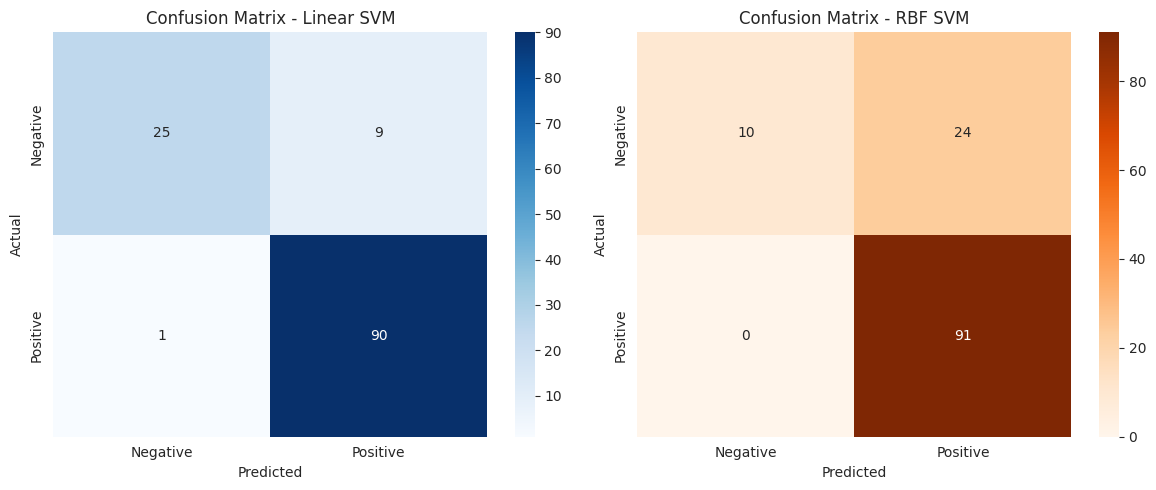

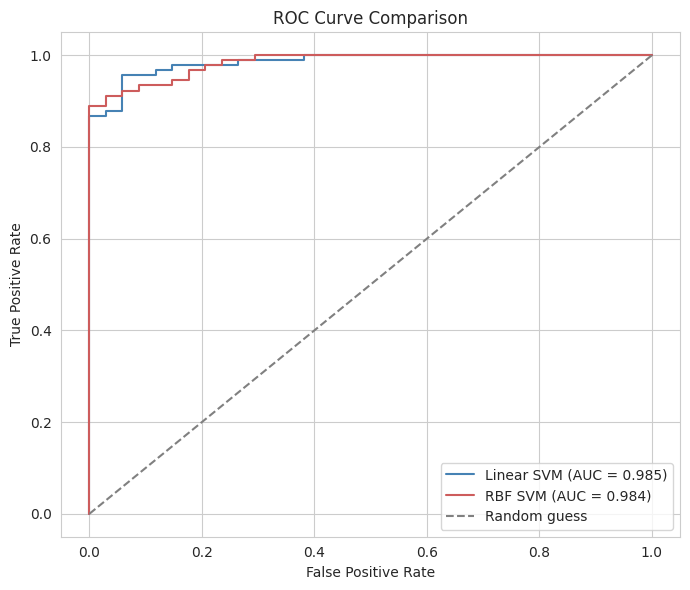


Linear SVM AUC: 0.985
RBF SVM AUC: 0.984


In [13]:
# Cell 12: Compare Both Models
# Evaluate both kernels on the same held-out test set using several metrics,
# since accuracy alone can be misleading on an imbalanced dataset like this one.

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

linear_results = evaluate_model(linear_svm, X_test, y_test, 'Linear SVM')
rbf_results = evaluate_model(rbf_svm, X_test, y_test, 'RBF SVM')

# Clean comparison table of the core metrics
comparison_table = pd.DataFrame([
    {k: v for k, v in linear_results.items() if k not in ['y_pred', 'y_proba']},
    {k: v for k, v in rbf_results.items() if k not in ['y_pred', 'y_proba']}
]).set_index('Model').round(3)

print("Model comparison:")
display(comparison_table)
comparison_table.to_csv(tables_path / 'model_comparison.csv')

# Confusion matrices for both models, side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, results, cmap in zip(axes, [linear_results, rbf_results], ['Blues', 'Oranges']):
    cm = confusion_matrix(y_test, results['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    ax.set_title(f"Confusion Matrix - {results['Model']}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(charts_path / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC curve comparison
plt.figure(figsize=(7, 6))
for results, color in zip([linear_results, rbf_results], ['steelblue', 'indianred']):
    fpr, tpr, _ = roc_curve(y_test, results['y_proba'])
    roc_auc = auc(fpr, tpr)
    results['AUC'] = roc_auc
    plt.plot(fpr, tpr, color=color, label=f"{results['Model']} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(charts_path / 'roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nLinear SVM AUC: {linear_results['AUC']:.3f}")
print(f"RBF SVM AUC: {rbf_results['AUC']:.3f}")

Variance captured by the 2 principal components: 1.9%


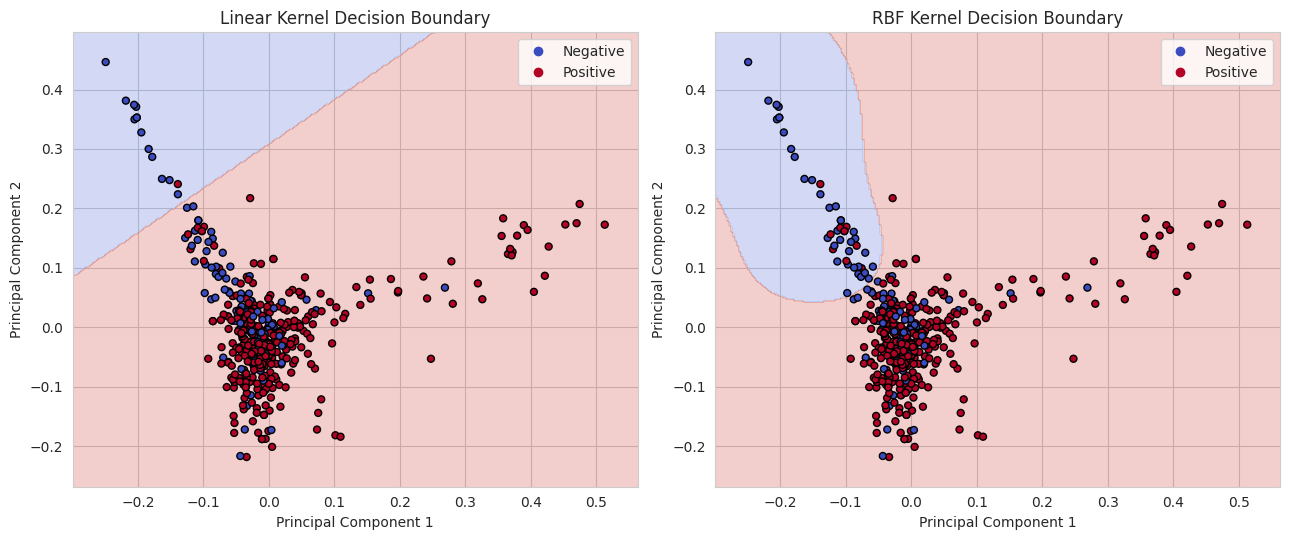

In [14]:
# Cell 13: Decision Boundary Visualization
# The TF-IDF feature space has 1000 dimensions, which cannot be plotted
# directly. PCA compresses the training data down to just 2 principal
# components that capture as much variance as possible, making it possible to
# draw and see a 2D decision boundary.
#
# Note: because TF-IDF text data is high-dimensional and sparse, 2 components
# only capture a small slice of the total variance, so these plots are meant to
# illustrate HOW each kernel separates classes rather than to represent the
# full-feature model's real performance (that was already measured in Cell 12).

pca = PCA(n_components=2, random_state=42)
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()
X_train_pca = pca.fit_transform(X_train_dense)

explained_variance = pca.explained_variance_ratio_.sum()
print(f"Variance captured by the 2 principal components: {explained_variance:.1%}")

# Train fresh, small SVMs directly on the 2D PCA data purely for visualization
linear_svm_2d = SVC(kernel='linear', C=1.0, random_state=42).fit(X_train_pca, y_train)
rbf_svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42).fit(X_train_pca, y_train)

def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.05, X[:, 0].max() + 0.05
    y_min, y_max = X[:, 1].min() - 0.05, X[:, 1].max() + 0.05
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=25)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.set_title(title)
    ax.legend(handles=scatter.legend_elements()[0], labels=list(label_encoder.classes_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_decision_boundary(linear_svm_2d, X_train_pca, y_train, 'Linear Kernel Decision Boundary', axes[0])
plot_decision_boundary(rbf_svm_2d, X_train_pca, y_train, 'RBF Kernel Decision Boundary', axes[1])
plt.tight_layout()
plt.savefig(charts_path / 'decision_boundaries.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Cell 14: Model Interpretation
# Interpretation is based directly on the metrics computed in Cell 12, not assumed in advance.

better_model = 'Linear SVM' if linear_results['Accuracy'] >= rbf_results['Accuracy'] else 'RBF SVM'
acc_gap = abs(linear_results['Accuracy'] - rbf_results['Accuracy'])

print(f"Linear SVM  -> Accuracy: {linear_results['Accuracy']:.3f}, Precision: {linear_results['Precision']:.3f}, "
      f"Recall: {linear_results['Recall']:.3f}, F1: {linear_results['F1-Score']:.3f}, AUC: {linear_results['AUC']:.3f}")
print(f"RBF SVM     -> Accuracy: {rbf_results['Accuracy']:.3f}, Precision: {rbf_results['Precision']:.3f}, "
      f"Recall: {rbf_results['Recall']:.3f}, F1: {rbf_results['F1-Score']:.3f}, AUC: {rbf_results['AUC']:.3f}")

print(f"""
Which kernel performed better?
{better_model} achieved the higher accuracy and F1-score, with a gap of about
{acc_gap:.1%} between the two models. Both kernels reached a similarly high AUC,
meaning they can both rank Positive posts above Negative ones reasonably well,
but their accuracy and precision differ noticeably once a hard 0.5 decision
threshold is applied.

Why did this happen?
The confusion matrices in Cell 12 show the RBF kernel leans heavily toward
predicting the majority class (Positive), which inflates recall for Positive
posts but lowers precision by misclassifying more Negative posts. This is a
known pattern for RBF kernels on high-dimensional, sparse TF-IDF data: with
1000 word features, the data is already close to linearly separable, so the
extra flexibility of the RBF kernel does not add much benefit and instead
makes the boundary more sensitive to the class imbalance in the training data.
The linear kernel, by contrast, is a natural fit for this kind of high-dimensional
sparse text data and produced a more balanced confusion matrix.

Which model would be recommended?
Based on these results, the Linear kernel SVM is the recommended model for this
sentiment classification task, since it produced better accuracy, precision,
and F1-score without sacrificing AUC.
""")

Linear SVM  -> Accuracy: 0.920, Precision: 0.909, Recall: 0.989, F1: 0.947, AUC: 0.985
RBF SVM     -> Accuracy: 0.808, Precision: 0.791, Recall: 1.000, F1: 0.883, AUC: 0.984

Which kernel performed better?
Linear SVM achieved the higher accuracy and F1-score, with a gap of about
11.2% between the two models. Both kernels reached a similarly high AUC,
meaning they can both rank Positive posts above Negative ones reasonably well,
but their accuracy and precision differ noticeably once a hard 0.5 decision
threshold is applied.

Why did this happen?
The confusion matrices in Cell 12 show the RBF kernel leans heavily toward
predicting the majority class (Positive), which inflates recall for Positive
posts but lowers precision by misclassifying more Negative posts. This is a
known pattern for RBF kernels on high-dimensional, sparse TF-IDF data: with
1000 word features, the data is already close to linearly separable, so the
extra flexibility of the RBF kernel does not add much benefit and in

In [16]:
# Cell 15: Final Conclusion
# Summary of what this notebook accomplished.

print(f"""
CONCLUSION

This notebook built a binary sentiment classifier (Positive vs. Negative) using
Support Vector Machines on social media post text. Since the raw dataset used
over 190 fine-grained emotion labels, a keyword-based mapping first grouped
these into a clean binary target, and TF-IDF was used to turn the cleaned text
into numerical features.

Two SVM kernels were trained and compared on the same test set: a Linear
kernel and an RBF kernel. The Linear kernel reached {linear_results['Accuracy']:.1%} accuracy
and an F1-score of {linear_results['F1-Score']:.3f}, outperforming the RBF kernel's
{rbf_results['Accuracy']:.1%} accuracy and {rbf_results['F1-Score']:.3f} F1-score. Both models reached a
similarly strong AUC, but the Linear kernel produced more balanced predictions
across both classes.

Business applications:
A model like this could help a business automatically flag negative sentiment
in comments, reviews, or social media mentions in real time, allowing a support
or marketing team to prioritize the posts that need a response first, rather
than reading through every post manually.

Strengths and limitations:
SVMs handle high-dimensional, sparse text features well and gave strong results
here even without heavy tuning. That said, this model was trained on fewer than
700 labeled posts, and the binary labels were derived from a keyword mapping
rather than being provided directly, so performance on new, unseen data (or on
sarcasm and mixed emotions) is likely to be less reliable than these test
results suggest.
""")


CONCLUSION

This notebook built a binary sentiment classifier (Positive vs. Negative) using
Support Vector Machines on social media post text. Since the raw dataset used
over 190 fine-grained emotion labels, a keyword-based mapping first grouped
these into a clean binary target, and TF-IDF was used to turn the cleaned text
into numerical features.

Two SVM kernels were trained and compared on the same test set: a Linear
kernel and an RBF kernel. The Linear kernel reached 92.0% accuracy
and an F1-score of 0.947, outperforming the RBF kernel's
80.8% accuracy and 0.883 F1-score. Both models reached a
similarly strong AUC, but the Linear kernel produced more balanced predictions
across both classes.

Business applications:
A model like this could help a business automatically flag negative sentiment
in comments, reviews, or social media mentions in real time, allowing a support
or marketing team to prioritize the posts that need a response first, rather
than reading through every post man